# Wind / WAVES dynamic spectrum

Plots Wind / WAVES data covering the full instrument frequency range from the three receivers:

- **TNR** (Thermal Noise Receiver): 4 - 256 kHz, 32/16 channels per band (5 bands)
- **RAD1** (Radio Receiver Band 1): 20 - 1040 kHz, 256 channels
- **RAD2** (Radio Receiver Band 2): 1.075 - 13.825 MHz, 256 channels

Supports two data products, selected via `data_level` in the configuration cell:

- `'l2'` - per-receiver Level-2 files (`wi_l2_wav_{rad1,rad2,tnr}_*`, LESIA processing). PSD in V$^2$/Hz, three separate sweep cadences.
- `'h1'` - combined Hi-Res file (`wi_h1_wav_*`). Background-normalised intensity (`E_VOLTAGE_*`), single shared time axis across the three receivers.

Instrument reference: [NASA/CDAWeb Wind/WAVES page](https://spdf.gsfc.nasa.gov/pub/data/wind/waves/).

Two manual loaders (`pycdf`) are provided. An alternative based on `pyspedas` is included as a commented cell.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import LogNorm
import matplotlib as mpl
from pathlib import Path
from datetime import datetime
import requests
from spacepy import pycdf

# Use the precise matplotlib epoch (avoids ~10 us offsets in old matplotlib).
mpl.rcParams['date.epoch'] = '1970-01-01T00:00:00'
try:
    mdates.set_epoch('1970-01-01T00:00:00')
except RuntimeError:
    pass

# Unified plotting style for all dynamic spectra notebooks.
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

## Configuration


In [2]:
mydate = '2024-09-14'
year, month, day = mydate.split('-')

data_dir = './sample_data/wind'
outputs  = './outputs'
os.makedirs(data_dir, exist_ok=True)
os.makedirs(outputs, exist_ok=True)

# Which Wind/WAVES product to use: 'l2' or 'h1'.
data_level = 'l2'

# Reference floor for dB conversion. For L2 this is V^2/Hz; for h1 the
# E_VOLTAGE_* product is already background-normalised so the floor is
# dimensionless and 1.0 is a sensible default.
PSD_FLOOR = 1.0

## Helper functions


In [3]:
BASE = 'https://spdf.gsfc.nasa.gov/pub/data/wind/waves'

def _download_file(dir_url, fname, local, timeout, overwrite):
    if local.exists() and not overwrite:
        return local
    try:
        with requests.get(dir_url + fname, stream=True, timeout=timeout) as r:
            r.raise_for_status()
            with open(local, 'wb') as f:
                for chunk in r.iter_content(chunk_size=1 << 16):
                    f.write(chunk)
        return local
    except requests.RequestException as e:
        print(f'download failed: {e}')
        if local.exists():
            local.unlink()
        return None


def download_wind_waves(day, save_dir='.', level='l2',
                        instruments=('rad1', 'rad2', 'tnr'),
                        overwrite=False, timeout=30):
    """
    Download Wind/WAVES CDF files for one day from SPDF.

    Parameters
    ----------
    day : str or datetime.date
        'YYYY-MM-DD' or 'YYYYMMDD' if string.
    save_dir : str or Path
    level : {'l2', 'h1'}
        'l2' fetches three per-receiver files; 'h1' fetches the single combined file.
    instruments : iterable of {'rad1','rad2','tnr'}, only used when level='l2'.
    overwrite : bool
    timeout : float

    Returns
    -------
    level='l2' -> dict mapping instrument name to local Path (or None).
    level='h1' -> single Path (or None).
    """
    if isinstance(day, str):
        fmt = '%Y-%m-%d' if '-' in day else '%Y%m%d'
        day = datetime.strptime(day, fmt).date()

    date_str = day.strftime('%Y%m%d')
    year     = day.strftime('%Y')
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    if level == 'l2':
        out = {}
        for instr in instruments:
            dir_url = f'{BASE}/{instr}_l2/{year}/'
            try:
                listing = requests.get(dir_url, timeout=timeout).text
            except requests.RequestException as e:
                print(f'[{instr}] index unreachable: {e}')
                out[instr] = None
                continue
            versions = re.findall(rf'wi_l2_wav_{instr}_{date_str}_v(\d+)\.cdf', listing)
            if not versions:
                print(f'[{instr}] no file for {date_str}')
                out[instr] = None
                continue
            fname = f'wi_l2_wav_{instr}_{date_str}_v{max(versions, key=int)}.cdf'
            out[instr] = _download_file(dir_url, fname, save_dir / fname, timeout, overwrite)
        return out

    elif level == 'h1':
        dir_url = f'{BASE}/wav_h1/{year}/'
        try:
            listing = requests.get(dir_url, timeout=timeout).text
        except requests.RequestException as e:
            print(f'[h1] index unreachable: {e}')
            return None
        versions = re.findall(rf'wi_h1_wav_{date_str}_v(\d+)\.cdf', listing)
        if not versions:
            print(f'[h1] no file for {date_str}')
            return None
        fname = f'wi_h1_wav_{date_str}_v{max(versions, key=int)}.cdf'
        return _download_file(dir_url, fname, save_dir / fname, timeout, overwrite)

    else:
        raise ValueError(f"Unknown level: {level!r}; use 'l2' or 'h1'.")


def subtract_background_median(df):
    """
    Subtract a per-channel median background from a dynamic spectrum.

    Computes the median along the time axis (axis=0) for each frequency channel,
    then subtracts it from every time sample of that channel. Standard approach
    for highlighting transient emission against a slowly-varying background.

    df : pandas.DataFrame of shape (n_times, n_freqs). Index is time, columns are frequencies.
    """
    bkg = np.nanmedian(df.values, axis=0)
    return df - np.tile(bkg, (df.shape[0], 1))


def voltage_to_db(arr, floor=PSD_FLOOR):
    """
    Convert linear intensity to decibels above a reference floor.

    L2 `PSD_V2_*` is in V^2/Hz; the floor should be a PSD reference (default 1.0 V^2/Hz).
    h1 `E_VOLTAGE_*` is background-normalised intensity (ratio); log10 still yields a
    sensible display but the dB values are not absolute PSD levels.
    """
    return 10.0 * np.log10(np.asarray(arr, dtype=float) / floor)

## Download


In [4]:
paths = download_wind_waves(mydate, save_dir=data_dir, level=data_level)
print(paths)

{'rad1': PosixPath('sample_data/wind/wi_l2_wav_rad1_20240914_v01.cdf'), 'rad2': PosixPath('sample_data/wind/wi_l2_wav_rad2_20240914_v01.cdf'), 'tnr': PosixPath('sample_data/wind/wi_l2_wav_tnr_20240914_v01.cdf')}


## Load with `pycdf`

Both branches produce the same canonical variables: `wind_time_{TNR,RAD1,RAD2}`, `freq_{TNR,RAD1,RAD2}`, `spect_{TNR,RAD1,RAD2}`. The three receivers have separate time arrays for L2 (different sweep cadences) and identical ones for h1.


In [5]:
if data_level == 'l2':
    rad1_cdf = pycdf.CDF(str(paths['rad1']))
    rad2_cdf = pycdf.CDF(str(paths['rad2']))
    tnr_cdf  = pycdf.CDF(str(paths['tnr']))

    def _read_psd(cdf, var):
        """Read a PSD variable and mask FILLVAL and non-positive entries."""
        arr = np.asarray(cdf[var][...], dtype=float)
        fill = cdf[var].attrs.get('FILLVAL', None)
        if fill is not None:
            arr[arr == fill] = np.nan
        arr[arr <= 0] = np.nan
        return arr

    def read_l2(cdf, instrument):
        """
        Read a LESIA Wind/WAVES L2 CDF.

        For RAD1/RAD2 the three antenna-pair PSDs (S, SP, Z) are combined with a
        nan-aware maximum: different receiver modes populate different variables,
        so taking the max gives the most complete coverage. For TNR there is a
        single PSD_V2 variable.

        FREQUENCY in the L2 files is in Hz; converted to kHz to match h1.
        Channels are sorted into ascending frequency order — TNR's 5 overlapping
        octave bands make its native channel order non-monotonic, which would
        otherwise break pcolormesh.
        """
        t = np.asarray(cdf['Epoch'][...])
        f = np.asarray(cdf['FREQUENCY'][...], dtype=float)

        units = str(cdf['FREQUENCY'].attrs.get('UNITS', '')).strip().lower()
        if units == 'hz' or (units == '' and np.nanmax(f) > 1e5):
            f = f / 1e3

        if instrument == 'tnr':
            psd = _read_psd(cdf, 'PSD_V2')
        else:
            psd = np.fmax.reduce([
                _read_psd(cdf, 'PSD_V2_S'),
                _read_psd(cdf, 'PSD_V2_SP'),
                _read_psd(cdf, 'PSD_V2_Z'),
            ])

        sort_idx = np.argsort(f)
        return t, f[sort_idx], psd[:, sort_idx]

    wind_time_RAD1, freq_RAD1, spect_RAD1 = read_l2(rad1_cdf, 'rad1')
    wind_time_RAD2, freq_RAD2, spect_RAD2 = read_l2(rad2_cdf, 'rad2')
    wind_time_TNR,  freq_TNR,  spect_TNR  = read_l2(tnr_cdf,  'tnr')

    # QUALITY_FLAG (RAD1/RAD2 only) is available but bit-encoded; not used by default.
    q_RAD1 = np.asarray(rad1_cdf['QUALITY_FLAG'][...])
    q_RAD2 = np.asarray(rad2_cdf['QUALITY_FLAG'][...])

    for c in (rad1_cdf, rad2_cdf, tnr_cdf):
        c.close()

elif data_level == 'h1':
    # Accept either a Path from the downloader or a locally globbed file.
    if isinstance(paths, (str, Path)) and Path(paths).exists():
        h1_path = str(paths)
    else:
        local = sorted(glob.glob(f'{data_dir}/wi_h1*_wav_{year}{month}{day}*.cdf'))
        if not local:
            raise FileNotFoundError(f'No h1 file found for {mydate} in {data_dir}')
        h1_path = local[0]
    print(h1_path)

    wind = pycdf.CDF(h1_path)
    t_h1       = np.asarray(wind['Epoch'])
    freq_TNR   = np.asarray(wind['Frequency_TNR'])
    freq_RAD1  = np.asarray(wind['Frequency_RAD1'])
    freq_RAD2  = np.asarray(wind['Frequency_RAD2'])
    spect_TNR  = np.asarray(wind['E_VOLTAGE_TNR'],  dtype=float)
    spect_RAD1 = np.asarray(wind['E_VOLTAGE_RAD1'], dtype=float)
    spect_RAD2 = np.asarray(wind['E_VOLTAGE_RAD2'], dtype=float)
    wind.close()

    # h1 has a single shared time axis; replicate it for the per-receiver API
    wind_time_TNR  = t_h1
    wind_time_RAD1 = t_h1
    wind_time_RAD2 = t_h1

else:
    raise ValueError(f'Unknown data_level: {data_level!r}')

print(f'TNR : {freq_TNR.min():7.2f} - {freq_TNR.max():7.2f} kHz, '
      f'shape {spect_TNR.shape}, n_times {len(wind_time_TNR)}')
print(f'RAD1: {freq_RAD1.min():7.2f} - {freq_RAD1.max():7.2f} kHz, '
      f'shape {spect_RAD1.shape}, n_times {len(wind_time_RAD1)}')
print(f'RAD2: {freq_RAD2.min():7.2f} - {freq_RAD2.max():7.2f} kHz, '
      f'shape {spect_RAD2.shape}, n_times {len(wind_time_RAD2)}')

for name, f, psd in [('TNR', freq_TNR, spect_TNR),
                     ('RAD1', freq_RAD1, spect_RAD1),
                     ('RAD2', freq_RAD2, spect_RAD2)]:
    finite = np.isfinite(psd)
    print(f'{name}: finite={finite.mean():6.1%}, '
          f'PSD range=[{np.nanmin(psd):.2e}, {np.nanmax(psd):.2e}], '
          f'monotonic_f={bool(np.all(np.diff(f) > 0))}')

TNR :    4.09 -  250.51 kHz, shape (19136, 96), n_times 19136
RAD1: -9999999848243207893243920384.00 - 1040.00 kHz, shape (1772, 256), n_times 1772
RAD2: 1075.00 - 13825.00 kHz, shape (5186, 256), n_times 5186
TNR: finite=100.0%, PSD range=[1.94e-16, 4.66e-10], monotonic_f=True
RAD1: finite= 12.5%, PSD range=[1.91e-15, 5.99e-11], monotonic_f=False
RAD2: finite=100.0%, PSD range=[1.95e-15, 2.23e-11], monotonic_f=True


## Alternative loader: `pyspedas`

Uncomment to fetch and parse Wind/WAVES h1 data via tplot instead.


In [6]:
# import pyspedas
# from pytplot import get_data
#
# wind_vars = pyspedas.wind.waves(trange=[mydate, mydate], no_update=True)
#
# tnr_t, tnr_v, freq_TNR  = get_data('E_VOLTAGE_TNR')
# r1_t,  r1_v,  freq_RAD1 = get_data('E_VOLTAGE_RAD1')
# r2_t,  r2_v,  freq_RAD2 = get_data('E_VOLTAGE_RAD2')
#
# wind_time_TNR  = pd.to_datetime(tnr_t, unit='s').to_pydatetime()
# wind_time_RAD1 = pd.to_datetime(r1_t,  unit='s').to_pydatetime()
# wind_time_RAD2 = pd.to_datetime(r2_t,  unit='s').to_pydatetime()
# spect_TNR, spect_RAD1, spect_RAD2 = tnr_v, r1_v, r2_v

## Convert to dB and pack into per-receiver DataFrames


In [7]:
df_TNR  = pd.DataFrame(voltage_to_db(spect_TNR).T,  index=freq_TNR,  columns=wind_time_TNR)
df_RAD1 = pd.DataFrame(voltage_to_db(spect_RAD1).T, index=freq_RAD1, columns=wind_time_RAD1)
df_RAD2 = pd.DataFrame(voltage_to_db(spect_RAD2).T, index=freq_RAD2, columns=wind_time_RAD2)

# Raw PSD (V^2/Hz for L2; normalised intensity for h1). Kept for LogNorm plotting.
df_TNR_raw  = pd.DataFrame(spect_TNR.T,  index=freq_TNR,  columns=wind_time_TNR)
df_RAD1_raw = pd.DataFrame(spect_RAD1.T, index=freq_RAD1, columns=wind_time_RAD1)
df_RAD2_raw = pd.DataFrame(spect_RAD2.T, index=freq_RAD2, columns=wind_time_RAD2)

# Replace inf/-inf (from log10(0)) with NaN before background removal.
for df in (df_TNR, df_RAD1, df_RAD2):
    df.replace([-np.inf, np.inf], np.nan, inplace=True)

print(f'TNR  shape (freq, time): {df_TNR.shape}')
print(f'RAD1 shape (freq, time): {df_RAD1.shape}')
print(f'RAD2 shape (freq, time): {df_RAD2.shape}')

TNR  shape (freq, time): (96, 19136)
RAD1 shape (freq, time): (256, 1772)
RAD2 shape (freq, time): (256, 5186)


## Plot the combined dynamic spectrum

The three receivers are drawn as separate `pcolormesh` layers on the same axes, each with its own time and frequency grid. For L2 the raw PSD is shown on a log colour scale (matches the CDAWeb / reference look). For h1 the already-normalised intensity is shown in dB after subtracting a per-channel median background.


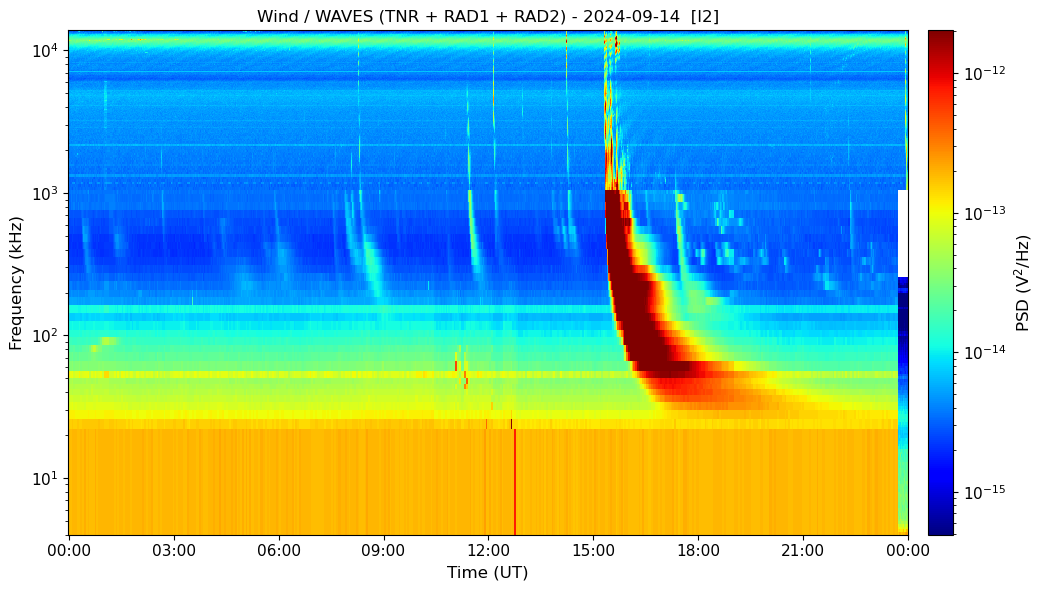

In [10]:
if data_level == 'l2':
    # raw PSD with log color scale — matches the standard CDAWeb/LESIA look
    panels = [df_TNR_raw, df_RAD1_raw, df_RAD2_raw]
    all_vals = np.concatenate([d.values.ravel() for d in panels])
    finite_vals = all_vals[np.isfinite(all_vals) & (all_vals > 0)]
    vmin = np.percentile(finite_vals, 5)
    vmax = np.percentile(finite_vals, 99.5)
    norm = LogNorm(vmin=vmin, vmax=vmax)
    cbar_label = 'PSD (V$^2$/Hz)'
    cmap = 'jet'
else:
    # background-subtracted dB — appropriate for h1's already-normalised intensity
    df_TNR_nobkg  = subtract_background_median(df_TNR.T).T
    df_RAD1_nobkg = subtract_background_median(df_RAD1.T).T
    df_RAD2_nobkg = subtract_background_median(df_RAD2.T).T
    panels = [df_TNR_nobkg, df_RAD1_nobkg, df_RAD2_nobkg]
    all_vals = np.concatenate([d.values.ravel() for d in panels])
    vmin = np.nanpercentile(all_vals, 50)
    vmax = np.nanpercentile(all_vals, 99)
    norm = None
    cbar_label = 'dB above per-channel median'
    cmap = 'Spectral_r'

fig, ax = plt.subplots(figsize=(11, 6))

for df_ in panels:
    if norm is not None:
        pc = ax.pcolormesh(df_.columns, df_.index, df_.values,
                           norm=norm, cmap=cmap, shading='nearest')
    else:
        pc = ax.pcolormesh(df_.columns, df_.index, df_.values,
                           vmin=vmin, vmax=vmax, cmap=cmap, shading='nearest')

fig.colorbar(pc, ax=ax, pad=0.02, label=cbar_label)

ax.set_yscale('log')
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Frequency (kHz)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_title(f'Wind / WAVES (TNR + RAD1 + RAD2) - {mydate}  [{data_level}]')

fig.tight_layout()
# fig.savefig(f'{outputs}/wind_dyspec_{mydate}_{data_level}.png', bbox_inches='tight')
plt.show()